# 03 · 训练 + 生成全流程（gpt2-tiny）

从一段文本到模型自己说话，走一遍完整闭环：

1. 建语料 → 滑窗数据集 → DataLoader；
2. 训练循环（AdamW + 交叉熵）；
3. 画 loss 曲线；
4. 贪婪解码与采样生成对比。

**用 `gpt2-tiny` 而不是 124M**：这一节在 CPU 上几十秒跑完。
注意 tiny 的 `context_length` 是 256（GPT-2 标准是 1024），所以它**不能**加载 HuggingFace 的
`gpt2` 权重——想加载真实权重请用 `configs/gpt2-small.yaml`。

In [1]:
from pathlib import Path

import torch

import my_llm
from my_llm.config import GPTConfig
from my_llm.data.dataloader import create_dataloader_v1
from my_llm.generate.sampling import generate
from my_llm.model.gpt import GPTModel
from my_llm.tokenizer import build_tokenizer
from my_llm.train.losses import calc_loss_batch, calc_loss_loader
from my_llm.utils.seed import set_seed

ROOT = Path(my_llm.__file__).resolve().parents[2]
DEVICE = "cpu"

set_seed(123)
cfg = GPTConfig.from_yaml(ROOT / "configs" / "gpt2-tiny.yaml")
model = GPTModel(cfg).to(DEVICE)
tok = build_tokenizer("gpt2")
print("参数量:", sum(p.numel() for p in model.parameters()) / 1e6, "M")
print("配置:", cfg)

参数量: 6.862464 M
配置: GPTConfig(vocab_size=50257, context_length=256, emb_dim=128, n_layers=2, n_heads=4, drop_rate=0.1, qkv_bias=True)


## 1. 语料与 DataLoader

语料直接写在 notebook 里（仓库不带数据文件，`data/raw/` 被 gitignore 了），
所以这一节**不依赖任何外部文件**。滑窗数据集按 `max_length` 切窗口、`stride` 决定步长。

In [2]:
corpus = (
    "Every effort moves you toward the goal. "
    "The quick brown fox jumps over the lazy dog. "
    "Practice makes progress, and progress makes confidence. "
) * 40
print("语料字符数:", len(corpus))

split = int(len(corpus) * 0.9)
train_loader = create_dataloader_v1(
    corpus[:split], tok, batch_size=2, max_length=32, stride=32, shuffle=True, drop_last=True
)
val_loader = create_dataloader_v1(
    corpus[split:], tok, batch_size=2, max_length=32, stride=32, shuffle=False, drop_last=False
)
x, y = next(iter(train_loader))
print("batch 形状:", tuple(x.shape), "targets:", tuple(y.shape))
print("训练批次数:", len(train_loader))

语料字符数: 5640
batch 形状: (2, 32) targets: (2, 32)
训练批次数: 15


## 2. 训练循环

用 `train/losses.py` 的 `calc_loss_batch`（`F.cross_entropy` 的 `mean` 归约，
这也是 SFT 里用 `-100` 屏蔽 padding 能生效的前提）。每 10 步记一次训练/验证 loss。

In [3]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
num_epochs = 2
log_every = 10

train_losses: list[float] = []
val_losses: list[float] = []
step = 0
for epoch in range(num_epochs):
    model.train()
    running, seen = 0.0, 0
    for xb, yb in train_loader:
        loss = calc_loss_batch(xb, yb, model, DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running += loss.item()
        seen += 1
        step += 1
        if step % log_every == 0:
            model.eval()
            with torch.no_grad():
                val = calc_loss_loader(val_loader, model, DEVICE, num_batches=2)
            model.train()
            train_losses.append(running / seen)
            val_losses.append(val)
            print(f"epoch {epoch} step {step:>3}  train {running / seen:.3f}  val {val:.3f}")
            running, seen = 0.0, 0

epoch 0 step  10  train 72.341  val 55.453


epoch 1 step  20  train 34.954  val 26.010


epoch 1 step  30  train 21.377  val 12.944


## 3. Loss 曲线

`utils/viz.py` 的 `plot_losses` 接受显式 `out_path` 并内部 `savefig`
（v1 是 `plt.show()` + 外部 `savefig`，无头环境会拿到空图，这里修掉了）。

已保存: /home/tachikoma/projects/llm-playground/oss-upgrade/v2-work/outputs/notebooks/tiny-loss.pdf


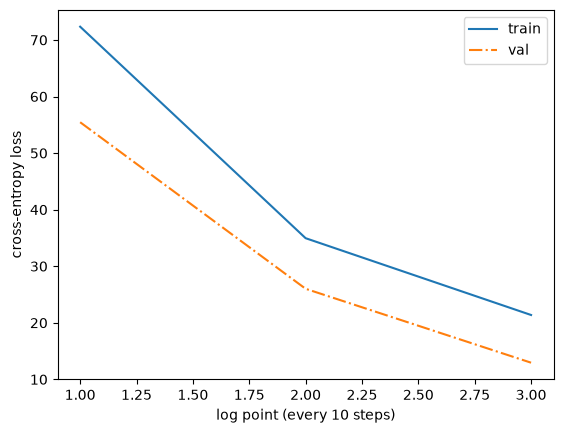

In [4]:
import matplotlib.pyplot as plt

from my_llm.utils.viz import plot_losses

saved = plot_losses(
    train_losses,
    val_losses,
    out_path=ROOT / "outputs" / "notebooks" / "tiny-loss.pdf",
)
print("已保存:", saved)

plt.plot(range(1, len(train_losses) + 1), train_losses, label="train")
plt.plot(range(1, len(val_losses) + 1), val_losses, linestyle="-.", label="val")
# 图内文字用英文：matplotlib 默认字体（DejaVu Sans）没有 CJK 字形，中文标签会变成方块
plt.xlabel(f"log point (every {log_every} steps)")
plt.ylabel("cross-entropy loss")
plt.legend()
plt.show()

## 4. 生成

同一个模型、同一个 prompt，比较：`temperature=0.0`（贪婪，每次都一样）与
`temperature=0.8` + top-k（有随机性，用 `set_seed` 保证可复现）。
tiny 模型只训了几十步，输出是"形似英文的字符汤"，这是正常的——重点是流程跑通。

In [5]:
model.eval()
prompt = "Every effort moves you"
idx = torch.tensor([tok.encode(prompt)])

with torch.no_grad():
    greedy = generate(model, idx, max_new_tokens=25, context_size=cfg.context_length, temperature=0.0)
print("贪婪:", tok.decode(greedy[0].tolist()))

set_seed(7)
gen = torch.Generator().manual_seed(7)
with torch.no_grad():
    sampled = generate(
        model, idx, max_new_tokens=25, context_size=cfg.context_length,
        temperature=0.8, top_k=10, generator=gen,
    )
print("采样:", tok.decode(sampled[0].tolist()))

贪婪: Every effort moves you you you you you you you you you you COP COP COP COP COP COP COP COP COP COP COP COP COP COP COP COP
采样: Every effort moves you you you you youTINGTINGTINGTINGTINGTINGTINGTINGTINGTINGTINGTINGTINGTINGTINGTINGTINGTINGTINGTINGTING


## 小结与下一步

- 想跑真正的预训练：`python scripts/train.py --config configs/gpt2-tiny.yaml --data <你的语料>`；
- 想看模型真的会说人话：用 `configs/gpt2-small.yaml` + HuggingFace 权重（见 README 的 Quick Start）；
- 想加速生成：`my_llm.generate.kv_cache.generate_with_cache`（实测 1.8x–2.4x，且与无 cache 路径逐 token 一致）。